In [55]:
%store -r

In [56]:
import boto3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from io import BytesIO
from PIL import Image
from torchvision import transforms

import sagemaker
from sagemaker.predictor import Predictor
from sagemaker.serializers import NumpySerializer
from sagemaker.deserializers import JSONDeserializer

In [57]:
training_manifest = pd.read_parquet("./data/processed/combined/training_manifest_021626.pqt")
non_cat_sample = training_manifest[(training_manifest["split"]=="test") & (training_manifest["label"]==0)].sample(5)
cat_sample = training_manifest[(training_manifest["split"]=="test") & (training_manifest["label"]==1)].sample(5)

input_sample = pd.concat([non_cat_sample, cat_sample])["remote_path"]

In [58]:
np.random.shuffle(input_sample.to_numpy())
input_sample

10339    s3://sagemaker-us-east-1-298748835671/cat-land...
11660    s3://sagemaker-us-east-1-298748835671/cat-land...
3690     s3://sagemaker-us-east-1-298748835671/cat-land...
4632     s3://sagemaker-us-east-1-298748835671/cat-land...
3860     s3://sagemaker-us-east-1-298748835671/cat-land...
3058     s3://sagemaker-us-east-1-298748835671/cat-land...
9192     s3://sagemaker-us-east-1-298748835671/cat-land...
1480     s3://sagemaker-us-east-1-298748835671/cat-land...
4367     s3://sagemaker-us-east-1-298748835671/cat-land...
4739     s3://sagemaker-us-east-1-298748835671/cat-land...
Name: remote_path, dtype: object

In [59]:
input_sample.shape

(10,)

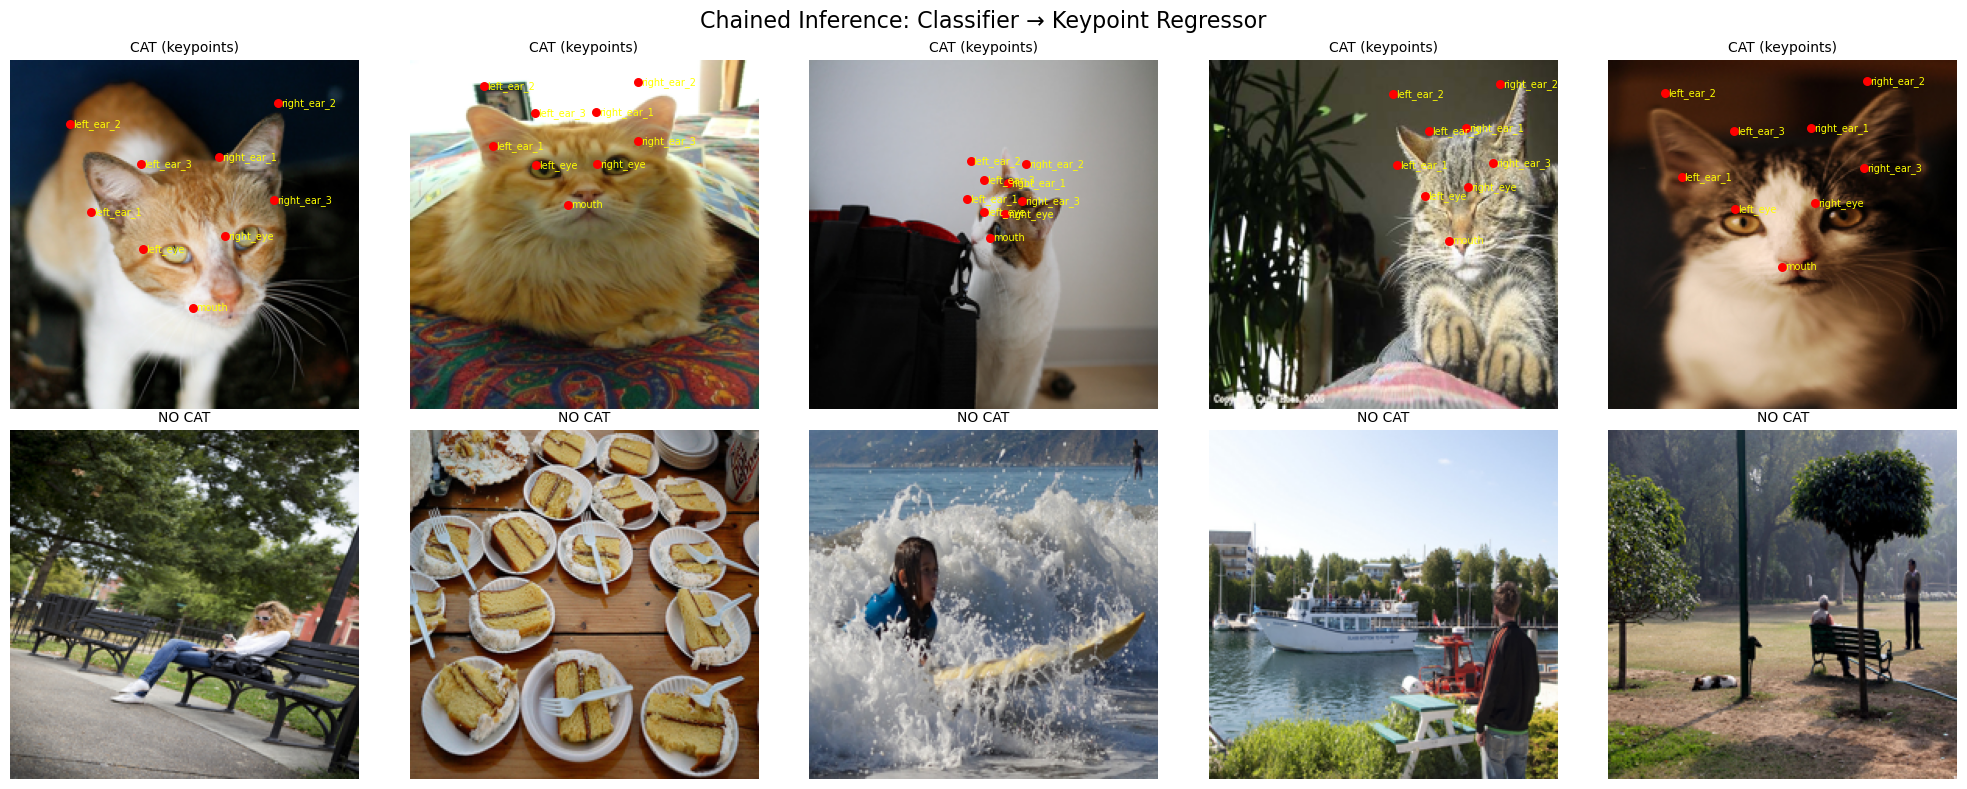

In [61]:
# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
IMAGE_SIZE = 224

S3_URIS = input_sample

KEYPOINT_NAMES = [
    "left_eye", "right_eye", "mouth",
    "left_ear_1", "left_ear_2", "left_ear_3",
    "right_ear_1", "right_ear_2", "right_ear_3",
]

sagemaker_session = sagemaker.Session()
classifier_endpoint_name = "cls-e41ed1f6-f8f9-4adc-9afd-335ab04e08bd"
kp_endpoint_name = "keypoint-regression-e41ed1f6-f8f9-4adc-9afd-335ab04e08bd"
# ---------------------------------------------------------------------
# SageMaker endpoints
# ---------------------------------------------------------------------
classifier_predictor = Predictor(
    endpoint_name=classifier_endpoint_name,
    sagemaker_session=sagemaker_session,
    serializer=NumpySerializer(),
    deserializer=JSONDeserializer(),
)

kp_predictor = Predictor(
    endpoint_name=kp_endpoint_name,
    sagemaker_session=sagemaker_session,
    serializer=NumpySerializer(),
    deserializer=JSONDeserializer(),
)

# ---------------------------------------------------------------------
# Transforms (must match training)
# ---------------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------
def load_image_from_s3(s3_uri: str) -> Image.Image:
    bucket, key = s3_uri.replace("s3://", "").split("/", 1)
    s3 = boto3.client("s3")
    obj = s3.get_object(Bucket=bucket, Key=key)
    return Image.open(BytesIO(obj["Body"].read())).convert("RGB")

def run_classifier(img_tensor: np.ndarray):
    """
    Returns:
        predicted_class (int): 0 = non-cat, 1 = cat
        predicted_label (str)
        cat_prob (float)
    """
    response = classifier_predictor.predict(img_tensor)

    predicted_class = int(response["predicted_class"])
    predicted_label = response["predicted_label"]
    cat_prob = float(response["probabilities"]["cat"])

    return predicted_class, predicted_label, cat_prob

def run_keypoint_regressor(img_tensor: np.ndarray) -> dict:
    """
    Returns:
        Dict[str, Dict[str, float]] mapping keypoint -> {x, y}
    """
    response = kp_predictor.predict(img_tensor)
    return response

# ---------------------------------------------------------------------
# Run pipeline
# ---------------------------------------------------------------------
results = []

for s3_uri in S3_URIS:
    image = load_image_from_s3(s3_uri)
    image_resized = image.resize((IMAGE_SIZE, IMAGE_SIZE))

    input_tensor = transform(image).unsqueeze(0).numpy()

    pred_class, pred_label, cat_prob = run_classifier(input_tensor)
    keypoints = None
    if pred_class == 1:
        keypoints = run_keypoint_regressor(input_tensor)
        
    results.append({
		"s3_uri": s3_uri,
		"image": image_resized,
		"label": pred_class,
		"label_name": pred_label,
		"cat_prob": cat_prob,
		"keypoints": keypoints,
	})

# ---------------------------------------------------------------------
# Select 5 cats + 5 non-cats
# ---------------------------------------------------------------------
cats = [r for r in results if r["label"] == 1][:5]
noncats = [r for r in results if r["label"] == 0][:5]

selected = cats + noncats
#assert len(selected) == 10, "Need at least 5 cats and 5 non-cats"

# ---------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, item in zip(axes, selected):
    ax.imshow(item["image"])
    ax.axis("off")

    if item["label"] == 1:
        for name, coords in item["keypoints"].items():
            x = coords["x"] * IMAGE_SIZE
            y = coords["y"] * IMAGE_SIZE
            ax.scatter(x, y, c="red", s=30)
            ax.text(x + 2, y + 2, name, fontsize=7, color="yellow")
            ax.set_title("CAT (keypoints)", fontsize=10)
    else:
        ax.set_title("NO CAT", fontsize=10)

plt.suptitle("Chained Inference: Classifier → Keypoint Regressor", fontsize=16)
plt.tight_layout()
plt.show()